# SHAP Explainability — AQI Prediction Models

Explains the Random Forest models actually produced by the last `main_train.py` run, loaded from `training_results.pkl`.

SHAP is applied via `TreeExplainer` and is **Random Forest only** — horizons where Ridge won will be skipped and noted below (currently RF wins all horizons, so this is mostly a safety net).

In [2]:
import sys
sys.path.append("..")

import joblib
import matplotlib.pyplot as plt

import os
os.chdir("C:\\Users\\abuhu\\Desktop\\Internship\\AQI-Pearls-Predictor")
print(os.getcwd())

from shap_explain import (
    explain_horizon,
    build_explainer,
    compute_shap_values,
    plot_dependence,
)

C:\Users\abuhu\Desktop\Internship\AQI-Pearls-Predictor


C:\Users\abuhu\Desktop\Internship\AQI-Pearls-Predictor\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load training results

Pickled at the end of `main_train.py`, right after `train_all_horizons()` and before promotion — so this reflects the exact challenger models evaluated in the last training run, not a fresh retrain.

In [3]:
training_results = joblib.load("training_results.pkl")

for h, r in training_results.items():
    if r is None:
        print(f"{h}h: training was skipped (insufficient samples)")
    else:
        print(f"{h}h: winner={r['winner_name']}, test_rmse={r['test_metrics']['rmse']:.3f}")

24h: winner=random_forest, test_rmse=17.070
48h: winner=ridge, test_rmse=17.716
72h: winner=random_forest, test_rmse=14.514


## Global + local SHAP plots per horizon

For each horizon: a summary (beeswarm) plot showing overall feature importance and direction of effect, plus waterfall plots for the best- and worst-predicted test rows.

`explain_horizon()` returns `None` for horizons where the winner isn't Random Forest, or where training itself was skipped — those are logged and skipped here rather than raising.

--- 24h horizon ---


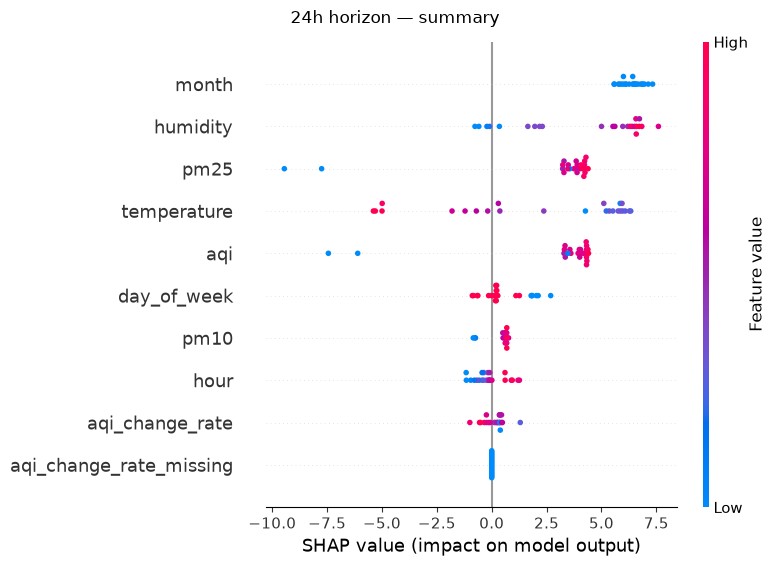

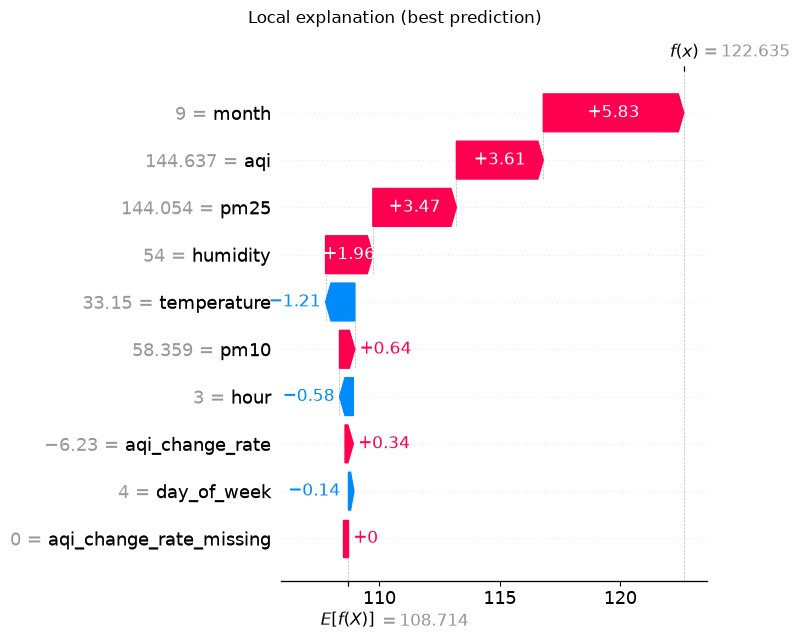

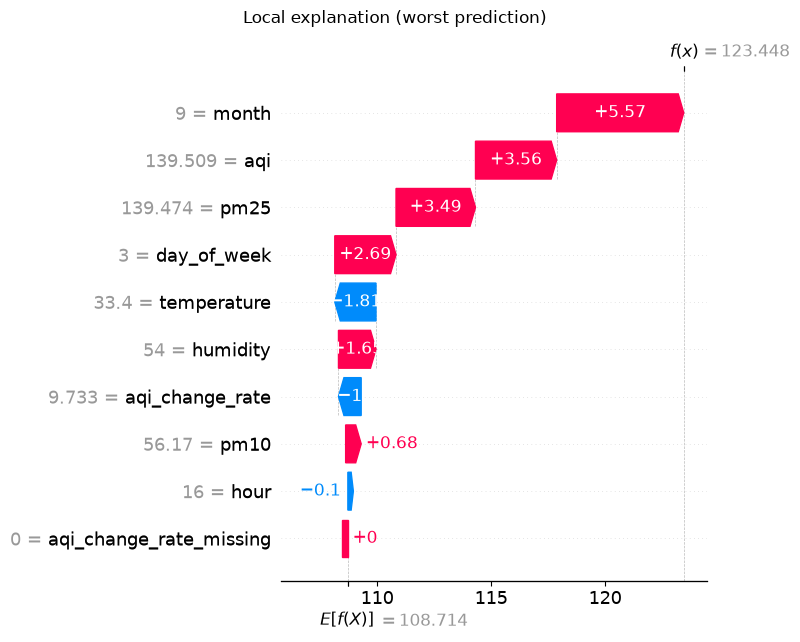

Horizon 48h: winner is 'ridge', not random_forest — SHAP skipped for this horizon.


--- 48h: skipped (not a Random Forest winner, or training skipped) ---
--- 72h horizon ---


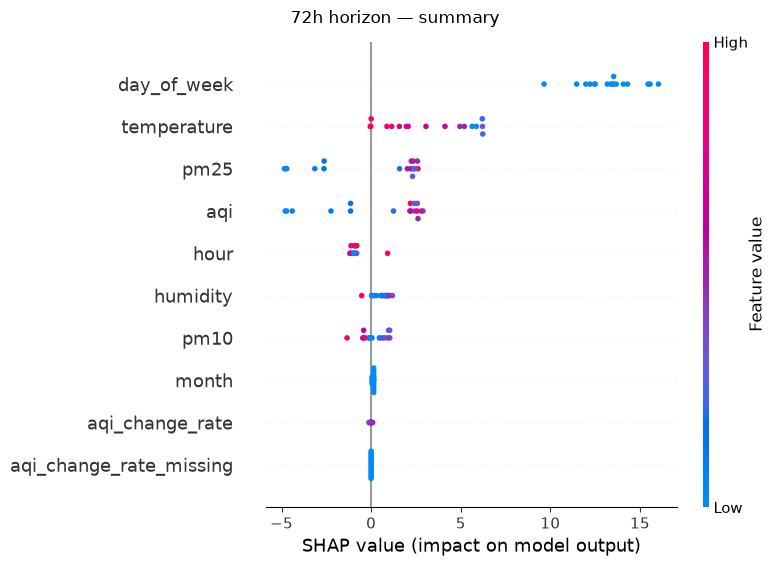

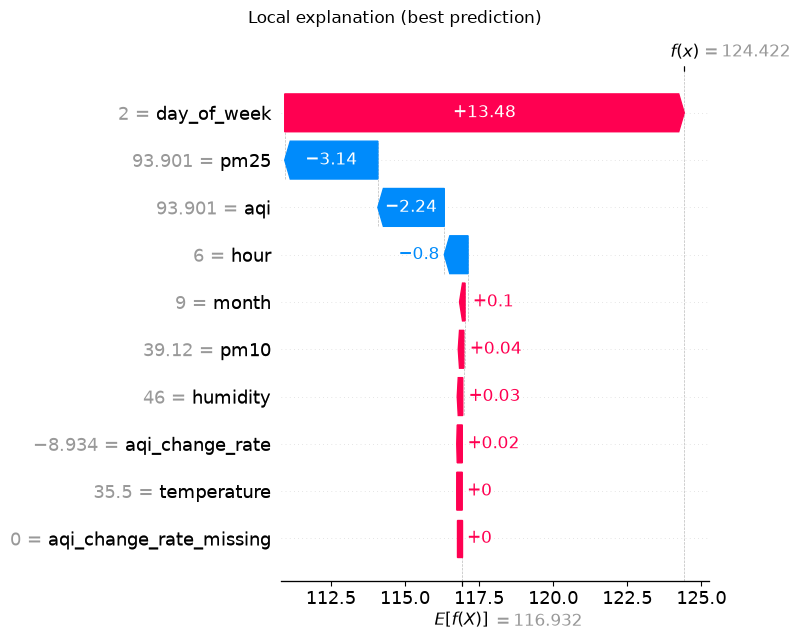

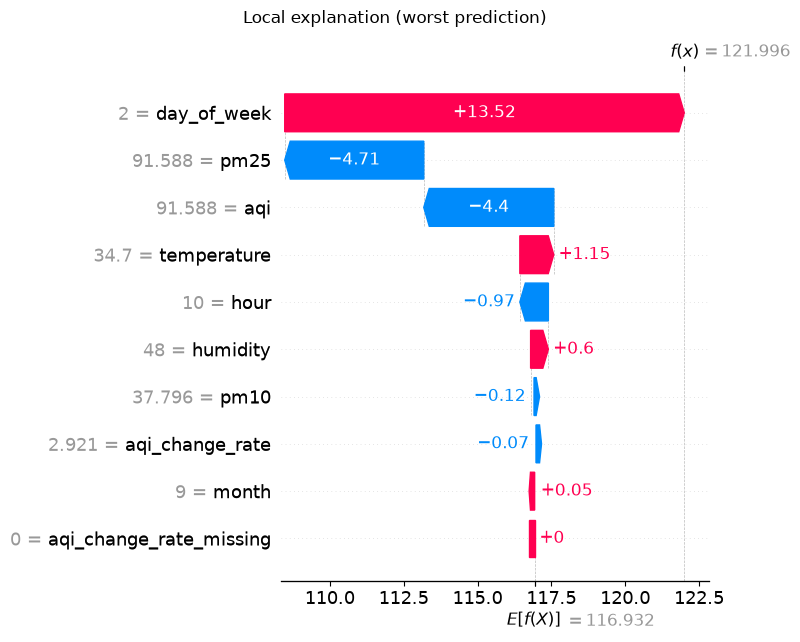

In [4]:
all_explanations = {}

for h, result in training_results.items():
    explanation = explain_horizon(result)
    all_explanations[h] = explanation

    if explanation is None:
        print(f"--- {h}h: skipped (not a Random Forest winner, or training skipped) ---")
        continue

    print(f"--- {h}h horizon ---")
    for name, fig in explanation.items():
        fig.suptitle(f"{h}h horizon — {name}", y=1.02)
        plt.show()

## Save figures to disk

Optional — run this if you want PNGs to drop into the final report.

In [5]:
for h, explanation in all_explanations.items():
    if explanation is None:
        continue
    for name, fig in explanation.items():
        fig.savefig(f"SHAP_FIGURES\shap_{h}h_{name}.png", bbox_inches="tight", dpi=150)

print("Saved SHAP figures.")

Saved SHAP figures.


## Dependence plots

Editorial choice, not automated per-horizon — pick the features worth spotlighting in the report (e.g. `aqi`, `pm25`, `aqi_change_rate`). These need `shap_values` directly, which `explain_horizon()` doesn't expose, so we recompute them here for the horizon(s) you want to look closer at.

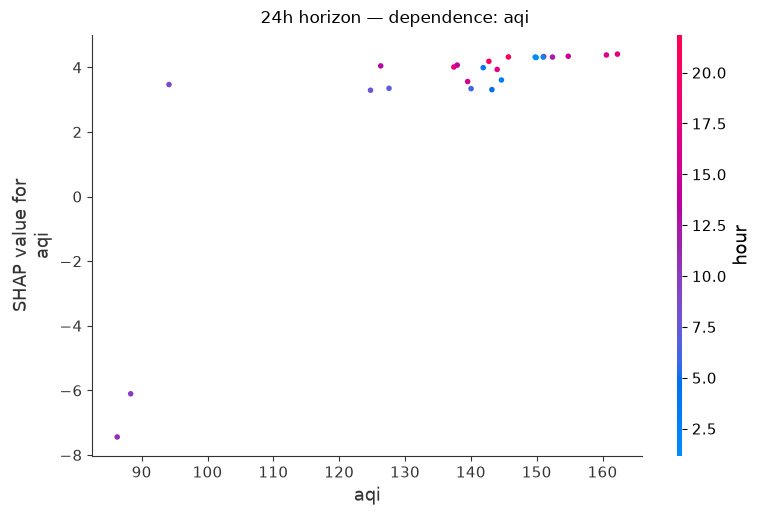

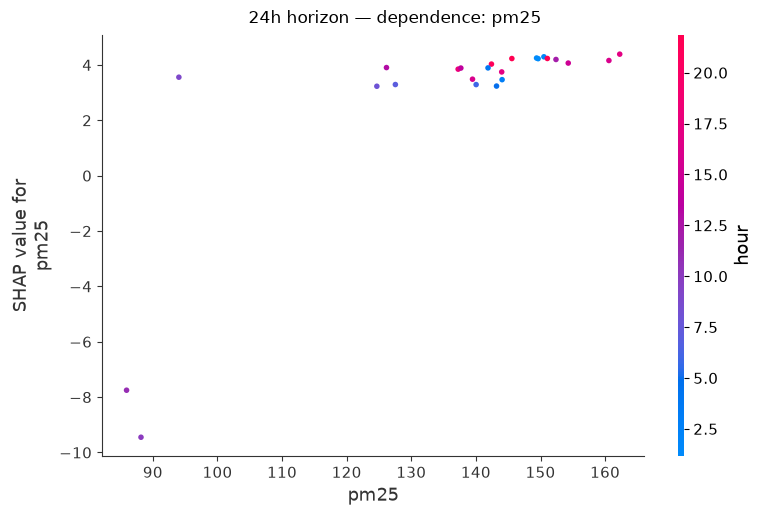

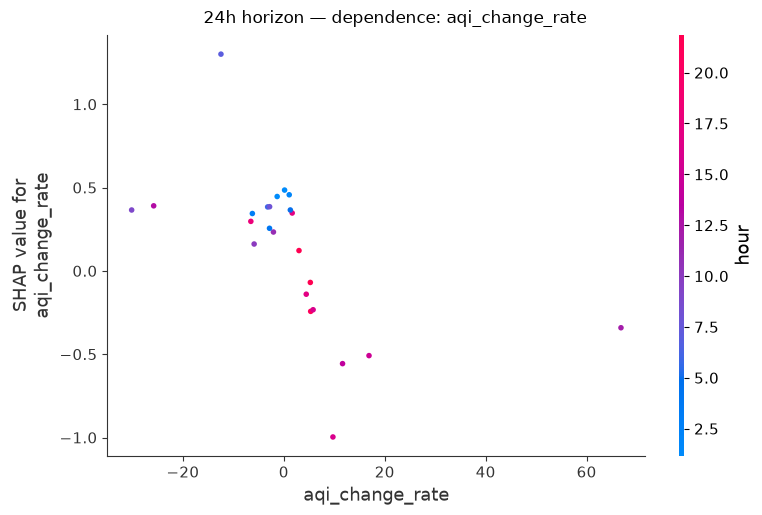

In [6]:
HORIZON_TO_INSPECT = 24  # change as needed
FEATURES_TO_INSPECT = ["aqi", "pm25", "aqi_change_rate"]

result = training_results[HORIZON_TO_INSPECT]

if result is None or result["winner_name"] != "random_forest":
    print(f"{HORIZON_TO_INSPECT}h: no Random Forest winner to inspect.")
else:
    explainer = build_explainer(result["winner_model"])
    shap_values = compute_shap_values(explainer, result["X_test"])

    for feature in FEATURES_TO_INSPECT:
        fig = plot_dependence(shap_values, result["X_test"], feature)
        fig.suptitle(f"{HORIZON_TO_INSPECT}h horizon — dependence: {feature}", y=1.02)
        plt.show()